# LSTM Neural Network for Affordability Metric

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
df = pd.read_csv('../data/processed/final_3d_df.csv')

In [3]:
base_features = ['county_perc_mo', 'mortgage_rate', 'income']
grouped = df.groupby('fips', sort=False)

for col in base_features:
    df[f'{col}_prev_1m'] = grouped[col].shift(1)
    df[f'{col}_prev_3m'] = grouped[col].shift(3)
    df[f'{col}_rolling_3m'] = grouped[col].transform(
        lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
    )
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype('float32')
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype('float32')

feature_columns = [col for col in df.columns 
                   if col.endswith('_prev_1m') or col.endswith('_prev_3m') 
                   or col.endswith('_rolling_3m') or col.endswith('_sin') or col.endswith('_cos')]
print(f"Feature columns: {feature_columns}")



Feature columns: ['county_perc_mo_prev_1m', 'county_perc_mo_prev_3m', 'county_perc_mo_rolling_3m', 'mortgage_rate_prev_1m', 'mortgage_rate_prev_3m', 'mortgage_rate_rolling_3m', 'income_prev_1m', 'income_prev_3m', 'income_rolling_3m', 'month_sin', 'month_cos']


In [4]:
df_clean = df.dropna(subset=['Affordability Metric'] + feature_columns).copy()
df_clean = df_clean.reset_index(drop=True)


In [11]:
X_feature = df_clean[feature_columns].values
y = df_clean['Affordability Metric'].values

df_clean['fips_code'] = pd.Categorical(df_clean['fips']).codes



X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X_feature).astype('float32')


y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten().astype('float32')


In [15]:
lookback = 3

def create_sequences(X, y, df, lookback=3):
    X_seq = []
    y_seq = []
    sequence_dates = []
    
    for fips in df['fips'].unique():
        county_idx = df[df['fips'] == fips].index.tolist()
        
        
        if len(county_idx) < lookback + 1:
            continue
        
        for i in range(lookback, len(county_idx)):
            X_seq.append(X[county_idx[i-lookback:i]])
            y_seq.append(y[county_idx[i]])
            sequence_dates.append(
                pd.Timestamp(
                    year=int(df.loc[county_idx[i], 'year']),
                    month=int(df.loc[county_idx[i], 'month']),
                    day=1
                )
            )
    
    return np.array(X_seq,), np.array(y_seq), np.array(sequence_dates)

X_seq, y_seq, sequence_dates = create_sequences(X_scaled, y_scaled, df_clean, lookback=lookback)


In [17]:
split_year = 2020
sequence_years = np.array([d.year for d in sequence_dates])


train_mask = sequence_years <= split_year
test_mask = sequence_years > split_year


X_train = X_seq[train_mask]
X_test = X_seq[test_mask]
y_train = y_seq[train_mask].reshape(-1, 1)
y_test = y_seq[test_mask].reshape(-1, 1)

## Build LSTM Model

In [19]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (lookback=3, n_features=11)

model = keras.Sequential([
    layers.LSTM(64, activation='relu', input_shape=input_shape, 
                return_sequences=True, 
                kernel_regularizer=keras.regularizers.l2(0.001),
                recurrent_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    layers.LSTM(32, activation='relu', return_sequences=False,
                kernel_regularizer=keras.regularizers.l2(0.001),
                recurrent_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.1),

    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

print(f"Input shape: {input_shape}")
print(f"Model architecture:")
model.summary()

Input shape: (3, 11)
Model architecture:


/opt/miniconda3/envs/ArtificialNeuralNetworks/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,545 (127.13 KB)

 Trainable params: 32,545 (127.13 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.0001,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )
    ]
)

Epoch 1/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.4144 - mae: 0.3666 - val_loss: 0.2363 - val_mae: 0.2778 - learning_rate: 0.0010
Epoch 2/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3268 - mae: 0.3148 - val_loss: 0.2345 - val_mae: 0.2675 - learning_rate: 0.0010
Epoch 3/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3239 - mae: 0.3140 - val_loss: 0.2202 - val_mae: 0.2738 - learning_rate: 0.0010
Epoch 4/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3099 - mae: 0.3065 - val_loss: 0.2032 - val_mae: 0.2611 - learning_rate: 0.0010
Epoch 5/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2946 - mae: 0.3009 - val_loss: 0.1859 - val_mae: 0.2580 - learning_rate: 0.0010
Epoch 6/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2963 - mae: 0.2970 - val_loss: 0.1921 - val_mae: 0.2620 - learning_rate: 0.0010
Epoch 7/100
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2978 - mae: 0.2979 - val_loss: 0.1709 - val_mae: 0.2528 - learnin

## Evaluate Model Performance

In [24]:

y_train_pred_scaled = model.predict(X_train, verbose=0)
y_test_pred_scaled = model.predict(X_test, verbose=0)


y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)
y_train_original = y_scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_original = y_scaler.inverse_transform(y_test.reshape(-1, 1))


train_mse = mean_squared_error(y_train_original, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train_original, y_train_pred)
train_r2 = r2_score(y_train_original, y_train_pred)


test_mse = mean_squared_error(y_test_original, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_original, y_test_pred)
test_r2 = r2_score(y_test_original, y_test_pred)


train_mean = np.mean(y_train_original)
baseline_test_pred = np.full_like(y_test_original, train_mean)
baseline_mse = mean_squared_error(y_test_original, baseline_test_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test_original, baseline_test_pred)
baseline_r2 = r2_score(y_test_original, baseline_test_pred)



print("TRAIN SET METRICS")
print(f"MSE:  {train_mse:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"MAE:  {train_mae:.6f}")
print(f"R²:   {train_r2:.6f}")


print("TEST SET METRICS")

print(f"MSE:  {test_mse:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"MAE:  {test_mae:.6f}")
print(f"R²:   {test_r2:.6f}")


print("BASELINE (Predict Training Mean)")

print(f"Baseline prediction: {train_mean:.2f}")
print(f"MSE:  {baseline_mse:.6f}")
print(f"RMSE: {baseline_rmse:.6f}")
print(f"MAE:  {baseline_mae:.6f}")
print(f"R²:   {baseline_r2:.6f}")


TRAIN SET METRICS
MSE:  491.049957
RMSE: 22.159647
MAE:  13.495740
R²:   0.770774
TEST SET METRICS
MSE:  273.759888
RMSE: 16.545691
MAE:  12.036148
R²:   0.855804
BASELINE (Predict Training Mean)
Baseline prediction: 129.43
MSE:  2441.459229
RMSE: 49.411125
MAE:  40.039719
R²:   -0.285973


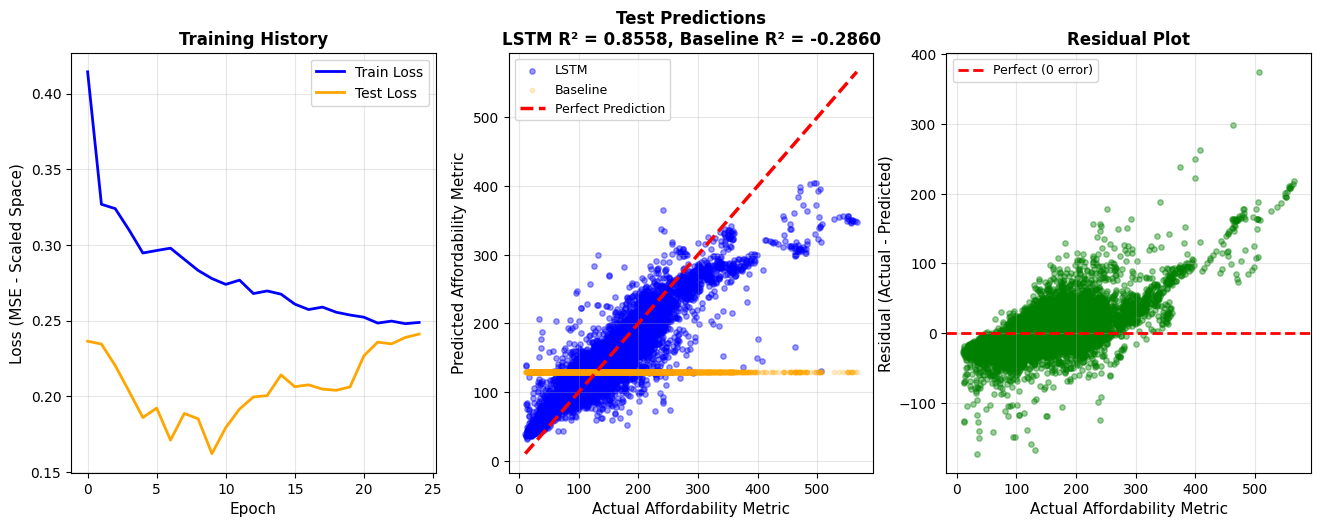

In [ ]:
fig = plt.figure(figsize=(16, 12))

# 1. Training Loss
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Test Loss', linewidth=2, color='orange')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (MSE - Scaled Space)', fontsize=11)
ax1.set_title('Training History', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Actual vs Predicted - Scatter Plot
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(y_test_original, y_test_pred, alpha=0.4, s=15, color='blue', label='LSTM')
ax2.scatter(y_test_original, baseline_test_pred, alpha=0.2, s=10, color='orange', label='Baseline')
min_val = min(y_test_original.min(), y_test_pred.min())
max_val = max(y_test_original.max(), y_test_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='Perfect Prediction')
ax2.set_xlabel('Actual Affordability Metric', fontsize=11)
ax2.set_ylabel('Predicted Affordability Metric', fontsize=11)
ax2.set_title(f'Test Predictions\nLSTM R² = {test_r2:.4f}, Baseline R² = {baseline_r2:.4f}', 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Residuals (Errors)
ax3 = plt.subplot(2, 3, 3)
test_residuals = y_test_original - y_test_pred
ax3.scatter(y_test_original, test_residuals, alpha=0.4, s=15, color='green')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Perfect (0 error)')
ax3.set_xlabel('Actual Affordability Metric', fontsize=11)
ax3.set_ylabel('Residual (Actual - Predicted)', fontsize=11)
ax3.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

